# Cartografía Colombia

**Autor:** Andres Felipe Sierra

**Objetivo:** Análisis y preparación de los datos cartografico para tener como base el mapa de Colombia con sus limites, cuencas, etc. 

**Apreciaciones:** Este script tiene la implementación de CRISP-DM con los respectivos ciclos siendo: Bussiness understanding, Data understanding, Data preparation, Modeling, Evaluation y Deployment.

## Bussiness understanding

La cartografía es base para tener los límites, Hidrografía, el riesgo, Relieve e infraestructura gracias al esqueleto geográfico para montar los datos climáticos y satelitales.

Además, el modelo se puede apoyar en cartografía oficial del IGAC a escala 1:100.000.

La base de datos que se utilizará es obtenida por el IGAC en el portal Geoespacial que posee la cartografía de Colombia. La información clave en cuanto a la hidrografía es: Ríos, Drenajes, Cuencas, Zonas bajas con lo anterior se puede sacar distancia de ríos, drenaje y una correlación con eventos UNGRD. Igualmente, es clave la información de los relieves sin reemplazar los datos topográficos.

## Librerías


In [ ]:
import geopandas as gpd
import fiona
from pathlib import Path

import pandas as pd

## Funciones

#### Funciones de la exploración

In [2]:
# Función para obtener los datos .gpkg
def get_gpkg(dat):
    gpk = Path(dat)
    return gpk

In [3]:
# Función para drenar
def drenar(dat,na):
    da = gpd.read_file(dat,layer=na).to_crs(epsg=3116)
    return da

In [4]:
# Función para unificar los drenajes (si es el caso)
def unificar_drenajes(dat1,dat2):
    da = gpd.GeoDataFrame(
        pd.concat([dat1, dat2], ignore_index=True),
        crs=3116
    )
    da.geom_type.value_counts()
    return da

In [5]:
# Función para proyectar a metros
def reproyectar_metros(dat):
    da = dat.to_crs(epsg=3116)
    da.crs
    return da

In [6]:
# Función para extraer los primeros dos dígitos del código municipal y generar una nueva columna de los códigos de los departamentos
def definicion_departamentos_code(dat):
    dat['Depto_Codigo'] = dat['MpCodigo'].str[:2]

    # Observamos cuántos departamentos únicos hay
    print(dat['Depto_Codigo'].unique())
    
    return dat

#### Funciones de la preparación

In [7]:
# Función para obtener los municipios en los poligonos
def municipios_poligono(dat,na):
    da = gpd.read_file(dat, layer=na)
    da = da.rename(columns={"geometry": "geometry"})  # por claridad
    return da


In [8]:
# Función para la revisión 
def revision_municipios(dat):
    print("CRS:", dat.crs)
    print("Rows:", len(dat))
    print(dat[["MpCodigo", "MpNombre", "Depto_Codigo"]].head())

In [9]:
# Función para limpiar las geometrías nulas o inválidas
def Limpiar_geometria(dat):
    da = dat[dat.geometry.notna()].copy()
    da["is_valid"] = da.is_valid
    invalid = (~da["is_valid"]).sum()
    print("Invalid geometries:", invalid)
    
    # Buffer(0) suele arreglar muchas invalidaciones simples
    if invalid > 0:
        da["geometry"] = da.buffer(0)
        da["is_valid"] = da.is_valid
        print("Invalid after fix:", (~da["is_valid"]).sum())
    
    return da

In [10]:
# Función para validar que el área coincida con el área geométrica
def Validacion_area(dat):
    dat["area_geom_km2"] = dat.geometry.area / 1e6  # m² -> km²

    # En dado caso que el MpArea estuviera en km², debería correlacionar y ser del mismo orden.
    dat["MpArea_num"] = pd.to_numeric(dat["MpArea"], errors="coerce")

    print(dat[["MpArea_num", "area_geom_km2"]].describe())

    # Miramos una una muestra
    dat[["MpNombre", "MpArea_num", "area_geom_km2"]].sample(10, random_state=7)
    return dat

In [11]:
# Función para cargar los datos hidrograficos
def cargue_hidrografia(gpkg,lay_l):
    gdfs = []
    for lyr in lay_l:
        if lyr in fiona.listlayers(gpkg):
            g = gpd.read_file(gpkg, layer=lyr).to_crs(epsg=3116)
            g["source_layer"] = lyr
            g = g[g.geometry.notna()].copy()
            gdfs.append(g)

    h_l= gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=3116)

    print(h_l.shape)
    print(h_l.geom_type.value_counts())

    return h_l

In [12]:
# Función para generar caracteristicas core para la manipulación en ML
def densidad_drenaje(dat, h_l):
    h_l["len_km"] = h_l.geometry.length / 1000 # Longitud por segmento en km

    join = gpd.sjoin(h_l[["len_km", "geometry"]], dat[["MpCodigo", "geometry"]], predicate="intersects") # Spatial join: Ayuda a asignar cada segmento al municipio que intersecta

    len_by_mun = join.groupby("MpCodigo")["len_km"].sum().reset_index() # Sumar longitud por municipio

    dat = dat.merge(len_by_mun, on="MpCodigo", how="left")     # Merge a municipios
    dat["len_km"] = dat["len_km"].fillna(0)

    dat["drenaje_km_por_km2"] = dat["len_km"] / dat["area_geom_km2"]   # Densidad

    dat[["MpCodigo", "MpNombre", "area_geom_km2", "len_km", "drenaje_km_por_km2"]].head()

    return dat

In [13]:
#Funcion paara generar centroides municipales
def centroides_municipales(dat,h_l):
    cent = dat[["MpCodigo", "geometry"]].copy()
    cent["geometry"] = cent.geometry.centroid
    cent = cent.set_geometry("geometry")

    # nearest join (requiere geopandas >= 0.10 aprox)
    nearest = gpd.sjoin_nearest(
        cent,
        h_l[["geometry"]].copy(),
        how="left",
        distance_col="dist_dren_m"
    )

    dat = dat.merge(nearest[["MpCodigo", "dist_dren_m"]], on="MpCodigo", how="left")
    dat["dist_dren_m"] = dat["dist_dren_m"].fillna(dat["dist_dren_m"].max())

    dat[["MpCodigo", "MpNombre", "dist_dren_m"]].head()
    return dat


In [14]:
# Función para conocer qué porcentaje tiene un municipio en cuanto a humedales o cuerpos de agua
def Proporcion_cuerpoagua_municipio(dat1, dat2, lay):
    wet_gdfs = []
    for lyr in lay:
        if lyr in fiona.listlayers(dat1):
            g = gpd.read_file(dat1, layer=lyr).to_crs(epsg=3116)
            g = g[g.geometry.notna()].copy()
            wet_gdfs.append(g)

    wet = gpd.GeoDataFrame(pd.concat(wet_gdfs, ignore_index=True), crs=3116)
   
    inter = gpd.overlay(dat2[["MpCodigo", "geometry"]], wet[["geometry"]], how="intersection")  # Intersección municipio–humedales
    inter["wet_km2"] = inter.geometry.area / 1e6

    wet_by_mun = inter.groupby("MpCodigo")["wet_km2"].sum().reset_index()

    dat2 = dat2.merge(wet_by_mun, on="MpCodigo", how="left")
    dat2["wet_km2"] = dat2["wet_km2"].fillna(0)
    dat2["wet_pct_area"] = dat2["wet_km2"] / dat2["area_geom_km2"]

    dat2[["MpCodigo", "MpNombre", "wet_pct_area"]].head()
    return dat2

#### Funciones finales

In [15]:
# Función para guardar el dataset ya preparado
def guardar_data(dat, columnas, mant):
    # Asegurar numéricos
    for c in mant:
        if c in dat.columns:
            dat[c] = pd.to_numeric(dat[c], errors="coerce")

    mun_ml = dat[columnas].copy()
    mun_ml.to_csv("municipios_features_igac.csv", index=False)
    dat.to_file("municipios_features_igac.gpkg", layer="mun_features", driver="GPKG")

## Data understanding

### Cargue del dataset

In [16]:
# Obtenemos los datos
nombre = "../Data/Servicio-205_Geopackage_Colombia/Carto100000_Colombia_DI_2022_gpkg/Carto100000_Colombia_DI_2022.gpkg"
gpkg = get_gpkg(nombre)
gpkg_prueba = gpkg

### Prueba

In [17]:
# Listamos las capas dentro del GPGKG
layers = fiona.listlayers(gpkg_prueba)

layers[:], len(layers)

(['Arbol',
  'Planta_Tratamiento',
  'Construccion_Agua_P',
  'Parque_P',
  'Central_Energia',
  'Tapa_Camara',
  'Mina_P',
  'Construccion_P',
  'Administrativo_P_Departamental',
  'Administrativo_P',
  'Otros_Textos',
  'Torre',
  'Puente_P',
  'Antena',
  'Poste',
  'Paso_Nivel',
  'Peaje',
  'Terminal_P',
  'Punto_Geodesico',
  'Hito_Limite',
  'Punto_Cota_Fotogrametrica',
  'Punto_Aerotriangulacion',
  'Punto_Estereoscopico',
  'Punto_Topografico',
  'Punto_Nivelacion',
  'Jaguey_P_Departametal',
  'Manantial',
  'Jaguey_P',
  'Cienaga_P',
  'Nomenclatura',
  'Orografia',
  'Costero_Insular',
  'Helipuerto_P',
  'Aeropuerto_P',
  'Puerto_P',
  'Embarcadero_Muelle',
  'Lote_L',
  'Muro',
  'Construccion_Agua_L',
  'Terraplen',
  'Cerca',
  'Tuberia',
  'Red_Alta_Tension',
  'Puente_L',
  'Tunel',
  'Limite_Nacion',
  'Limite_Municipal_Linea',
  'Curva_Nivel',
  'Canal_Sencillo',
  'Raudal_Rapido',
  'Drenaje_Sencillo',
  'Catarata',
  'Madrevieja_L',
  'Linea_Costera',
  'Pista_Ate

In [18]:
# Abrimos una capa como prueba
layer_name = layers[1] # En este caso seleccionariamos Planta_Tratamiento
gdf = gpd.read_file(gpkg_prueba, layer=layer_name)

gdf.head(), gdf.crs, gdf.geom_type.value_counts()

(               NOMBRE_GEOGRAFICO PROYECTO SYMBOL FECHA     PK_CUE  \
 0  Planta de Tratamiento de Agua     None      1   NaT  2140420.0   
 1  Planta de Tratamiento de Agua     None      1   NaT  7833325.0   
 
                                  GLOBALID                         geometry  
 0  {87A0912D-62AB-4B1B-A2DF-3523F4723D22}  POINT (4737561.386 2734835.828)  
 1  {3E47B802-B272-4612-A36B-C0BEAB2C6311}  POINT (5111774.549 2910582.805)  ,
 <Projected CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MA ...>
 Name: MAGNA-SIRGAS / Origen-Nacional
 Axis Info [cartesian]:
 - [east]: Easting (metre)
 - [north]: Northing (metre)
 Area of Use:
 - undefined
 Coordinate Operation:
 - name: unnamed
 - method: Transverse Mercator
 Datum: Marco Geocentrico Nacional de Referencia
 - Ellipsoid: GRS 1980
 - Prime Meridian: Greenwich,
 Point    2
 Name: count, dtype: int64)

Text(0.5, 1.0, 'Planta_Tratamiento')

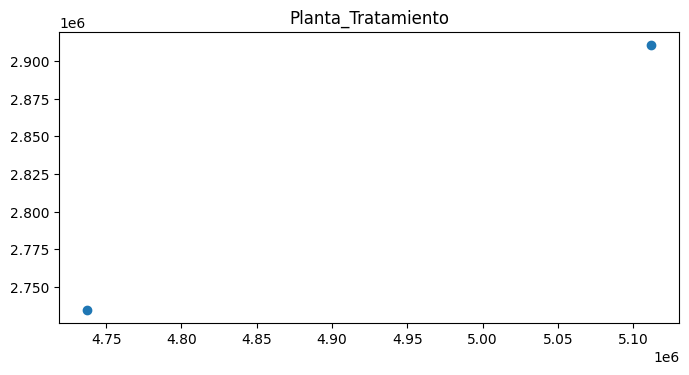

In [19]:
# Visualizamos la prueba
ax = gdf.plot(figsize=(8,8))
ax.set_title(layer_name)

### Exploración

Una vez verificado la funcionalidad y el posible contenido del dataset, se determina extraer para su preparación ciertas variables con importancia para la estructuración y unión con los datos CHIRPS con los evendos de la UNGRD.

Variables: 
* Limites de los gobiernos locales, es decir, los departamentales, limite municipal y nacional.
* Líneas de drenaje o ríos.
* Cuerpos hidricos.

In [20]:
# Comenzamos seleccionando las capas necesarias
core_layers = [
    "Limite_Departamental",
    "Limite_Municipal_Poligono",
    "Drenaje_Sencillo",
    "Drenaje_Doble",
    "Canal_Sencillo",
    "Canal_Doble",
    "Curva_Nivel",
    "Cienaga",
    "Laguna",
    "Pantano",
    "Humedal",
    "Embalse",
    "Otros_Cuerpos_Agua",
    "Madrevieja_L"
]

In [21]:
# Cargar municipios (base de agregación)
mun_prueba = gpd.read_file(gpkg_prueba, layer="Limite_Municipal_Poligono")
print(mun_prueba.shape, mun_prueba.crs)
mun_prueba.head()

(1122, 7) PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


,MpCodigo,MpNombre,MpArea,MpNorma,MpCategor,MpAltitud,geometry
0,91540,Puerto Nariño,1455.583518,Decreto No. 0106 de 1984,1,100,"MULTIPOLYGON (((5294748.315 1186216.201, 52959..."
1,91001,Leticia,6009.645080,Decreto No. 0352 de 1964,1,82,"MULTIPOLYGON (((5342445.115 1225820.782, 53423..."
2,91798,Tarapacá,9038.960497,NaN,3,100,"MULTIPOLYGON (((5385396.578 1336385.588, 52783..."
3,91263,El Encanto,10504.356901,NaN,3,158,"MULTIPOLYGON (((4946075.39 1392020.54, 4945975..."
4,91536,Puerto Arica,13473.880992,Ordenanza No. 023 de 1997,3,150,"MULTIPOLYGON (((5205586.571 1300159.591, 52056..."


In [22]:
mun_prueba.dtypes

MpCodigo          str
MpNombre          str
MpArea        float64
MpNorma           str
MpCategor       int32
MpAltitud       int16
geometry     geometry
dtype: object

Como podemos observar es la estructura del dato teniendo en cuenta que comenzaremos con la limitación del país. Sin embargo, por prácticidad y recomendación de IA, sería práctico normalizar los datos con un EPSG=3116 (European Petroleum Survey Group, paráetros geodésicos para cualquier software), el valor 3116 viene de un sistema MAGNA-SIRGAS/Colombia Bogota Zone, siendo elegido por prácticidad del territorio.

Puntos clave: 
* **Precisión Local:** 3116 usa coordenadas **planas (metros)** en lugar de grados. Ideal para medir distancias.
* **Zona Especifica:** Colombia se dividió en 5 zonas de proyección (Origen Bogotá, Este Oeste, etc.). Este corresponde al origen.
* **Marco Oficial:** Basado en el datum **MAGNA-SIRGAS**, que es el marco de referencia geocéntrico oficial adoptado por el IGAC (Instituto Geográfico Agustín Codazzi) para ser compatibles con diferentes entidades estatales.

Comenzamos a normalizar

### Normalización prueba

In [23]:
# Normalizamos con un epsg de 3116
mun_prueba = reproyectar_metros(mun_prueba)

In [24]:
# Se cargan los drenajes
dren1 = drenar(gpkg_prueba, "Drenaje_Sencillo")
dren2 = drenar(gpkg_prueba, "Drenaje_Doble")

c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 12033 in column FECHA, 1899-12-31T00:00:00.0Z, successfully parsed
  return ogr_read(
c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 92 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(


In [25]:
# Unificamos los drenajes
dren = unificar_drenajes(dren1, dren2)

Teniendo en cuenta que en el documento versión 2 integrado con las entregas anteriores, se evidenció con otra base de datos de la UNGRD que tres departamentos destacaban por ... estos departamentos son Bolívar, Sucre, Chocó, etc.

In [26]:
# Vemos las columnas
mun_prueba.columns

Index(['MpCodigo', 'MpNombre', 'MpArea', 'MpNorma', 'MpCategor', 'MpAltitud',
       'geometry'],
      dtype='str')

Según lo que vemos no tenemos el dato puntual del departamento, sin embargo, podemos buscar la cantidad de partamentos por el conteo de código de los municipios, de esta manera es posible determinar cuántos departamentos hay, verificando si se está yendo por un buen camino.

In [27]:
# Se extraer los primeros dos dígitos del código municipal
mun_prueba = definicion_departamentos_code(mun_prueba)

<ArrowStringArray>
['91', '97', '86', '52', '18', '19', '94', '41', '95', '00', '50', '73', '76',
 '25', '63', '27', '85', '11', '66', '15', '17', '99', '05', '68', '81', '54',
 '13', '23', '20', '70', '47', '08', '44', '88']
Length: 34, dtype: str


Vemos que hay un total de 34, dos números más de la cantidad de departamentos totales de Colombia, lo que se me ocurre que puede estar contando islas como Prividencia y San Andrés Islas y/o también incluye Bogotá como un solo departamento.

                                                   geometry MpCodigo  \
MpCodigo                                                               
00        POLYGON ((747777.582 757702.403, 747267.112 75...    00000   
05        POLYGON ((797296.716 1098289.812, 797281.213 1...    05145   
08        POLYGON ((913344.747 1635351.841, 913045.46 16...    08770   
11        POLYGON ((1000225.254 1026628.643, 1000204.307...    11001   
13        POLYGON ((897240.868 1545673.284, 897192.166 1...    13160   

                               MpNombre       MpArea  \
MpCodigo                                               
00        Area En Litigio Cauca - Huila   342.099087   
05                            Caramanta    92.062654   
08                                 Suan    42.513380   
11                         Bogotá, D.C.  1618.467680   
13                           Cantagallo   879.587548   

                           MpNorma  MpCategor  MpAltitud Depto_Codigo  
MpCodigo                      

<Axes: >

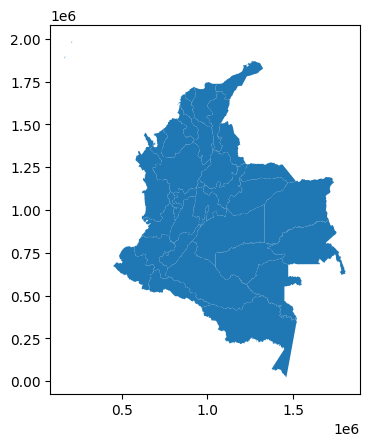

In [28]:
# Se agrupa por los primeros dos dígitos para crear los departamentos
departamentos = mun_prueba.dissolve(by=mun_prueba['MpCodigo'].str[:2])

# Esto devolverá un nuevo GeoDataFrame donde cada fila es un departamento
print(departamentos.head())
departamentos.plot()


Verificamos la estructura del dataframe

In [29]:
mun_prueba

,MpCodigo,MpNombre,MpArea,MpNorma,MpCategor,MpAltitud,geometry,Depto_Codigo
0,91540,Puerto Nariño,1455.583518,Decreto No. 0106 de 1984,1,100,"MULTIPOLYGON (((1414914.738 119244.231, 141617...",91
1,91001,Leticia,6009.645080,Decreto No. 0352 de 1964,1,82,"MULTIPOLYGON (((1462744.932 158874.984, 146268...",91
2,91798,Tarapacá,9038.960497,NaN,3,100,"MULTIPOLYGON (((1505876.312 269632.183, 139865...",91
3,91263,El Encanto,10504.356901,NaN,3,158,"MULTIPOLYGON (((1065940.705 325602.661, 106584...",91
4,91536,Puerto Arica,13473.880992,Ordenanza No. 023 de 1997,3,150,"MULTIPOLYGON (((1325706.381 233467.452, 132580...",91
...,...,...,...,...,...,...,...,...
1117,44430,Maicao,1767.249213,Decreto No. 0044 de 1956,1,51,"MULTIPOLYGON (((1226228.228 1785883.246, 12261...",44
1118,44560,Manaure,1616.125601,Ordenanza No. 15 de 1973,1,3,"MULTIPOLYGON (((1187786.339 1800256.065, 11877...",44
1119,44847,Uribia,7863.727320,NaN,1,23,"MULTIPOLYGON (((1262510.52 1870861.208, 126243...",44
1120,88001,San Andrés,27.398981,NaN,1,20,"MULTIPOLYGON (((169070.86 1896772.846, 169062....",88


Observando la teoría de que se están contando Providencias y Bogotá como departamentos aumentando así a 34, sin embargo, no se cumple la teoría necesitando
verificar los códigos, pero otra idea es en DAVIPOLA los códigos coinciden con esta base de datos, pero solo se muestran 33, el número 34 es el punto de origen de la cartografía. 

Continuaremos verificando los código.

| Código | Departamento | Código | Departamento | 
| :--- | :---: | :---: | ---: |
| 05 | Antioquia | 54 | Norte de Santander |
| 08 | Atlántico | 63 | Quindío |
| 11 | Bogotá, D.C. | 66 |	Risaralda |
| 13 | Bolívar | 68 | Santander |
| 15 | Boyacá | 70 | Sucre | 
| 17 | Caldas | 73	| Tolima |
| 18 | Caquetá | 76 | Valle del Cauca | 
| 19 | Cauca | 81 | Arauca |
| 20 | Cesar | 85 | Casanare |
| 23 | Córdoba | 86 | Putumayo | 
| 25 | Cundinamarca | 88 | San Andrés y Providencia |
| 27 | Chocó | 91 | Amazonas |
| 41 | Huila | 94 | Guainía |
| 44 | La Guajira | 95 | Guaviare |
| 47 | Magdalena | 97 | Vaupés |
| 50 | Meta | 99 | Vichada |
| 52 | Nariño | 00 | Área no definida / Marítima |

Con lo anterior, damos el visto bueno de la asignación de los códigos departamentales y municipales, usualmente el código de los departamentos corresponden a los dos primeros digitos al código del municipio, así se verificó.

#### Prueba recortando departamentos pilotos

In [30]:
# Se extrae los departamentos con índice alto de ...
deps = [13, 70, 27, 25]
mun_p = mun_prueba[mun_prueba["Depto_Codigo"].isin(deps)].copy()

In [31]:
# Se recorta los drenajes de la zona
dren_p = gpd.clip(dren, mun_p)

##### Features para ML

In [32]:
# Longitud drenajes (m) y área municipal (m²)
mun_p["area_km2"] = mun_p.geometry.area / 1e6

# Intersecar drenajes por municipio
join = gpd.sjoin(dren_p, mun_p[["geometry", "MpCodigo"]], predicate="intersects")

# calcular longitud por municipio
join["len_km"] = join.geometry.length / 1000
dens = join.groupby("MpCodigo")["len_km"].sum().reset_index()

mun_p = mun_p.merge(dens, on="MpCodigo", how="left").fillna({"len_km": 0})
mun_p["drenaje_km_por_km2"] = mun_p["len_km"] / mun_p["area_km2"]

mun_p[["MpCodigo", "area_km2", "len_km", "drenaje_km_por_km2"]].head()

,MpCodigo,area_km2,len_km,drenaje_km_por_km2


Lo anterior hace parte de la preparación para obtener la densidad del drenaje por municipio (km de río / km^2), pero siendo parte de la prueba.

In [33]:
# Volvemos a verificar las columnas
mun_prueba.columns

Index(['MpCodigo', 'MpNombre', 'MpArea', 'MpNorma', 'MpCategor', 'MpAltitud',
       'geometry', 'Depto_Codigo'],
      dtype='str')

## Data preparation

Teniendo en cuenta el entendimiento de los datos anteriores podemos proseguir con la preparación para su posterior uso.

Recordemos que mun = municipios

### Primera fase de la preparación de los datos

In [34]:
# Obtenemos los municipios por poligono
mun = municipios_poligono(gpkg,"Limite_Municipal_Poligono")

In [35]:
# Revisamos el datafram
mun

,MpCodigo,MpNombre,MpArea,MpNorma,MpCategor,MpAltitud,geometry
0,91540,Puerto Nariño,1455.583518,Decreto No. 0106 de 1984,1,100,"MULTIPOLYGON (((5294748.315 1186216.201, 52959..."
1,91001,Leticia,6009.645080,Decreto No. 0352 de 1964,1,82,"MULTIPOLYGON (((5342445.115 1225820.782, 53423..."
2,91798,Tarapacá,9038.960497,NaN,3,100,"MULTIPOLYGON (((5385396.578 1336385.588, 52783..."
3,91263,El Encanto,10504.356901,NaN,3,158,"MULTIPOLYGON (((4946075.39 1392020.54, 4945975..."
4,91536,Puerto Arica,13473.880992,Ordenanza No. 023 de 1997,3,150,"MULTIPOLYGON (((5205586.571 1300159.591, 52056..."
...,...,...,...,...,...,...,...
1117,44430,Maicao,1767.249213,Decreto No. 0044 de 1956,1,51,"MULTIPOLYGON (((5108626.681 2850491.771, 51085..."
1118,44560,Manaure,1616.125601,Ordenanza No. 15 de 1973,1,3,"MULTIPOLYGON (((5070287.426 2864994.058, 50702..."
1119,44847,Uribia,7863.727320,NaN,1,23,"MULTIPOLYGON (((5145194.35 2935212.66, 5145118..."
1120,88001,San Andrés,27.398981,NaN,1,20,"MULTIPOLYGON (((4051657.821 2965625.914, 40516..."


In [36]:
# Como lo realizado anteriormente se deben crear la nueva variable código del departament
mun = definicion_departamentos_code(mun)

<ArrowStringArray>
['91', '97', '86', '52', '18', '19', '94', '41', '95', '00', '50', '73', '76',
 '25', '63', '27', '85', '11', '66', '15', '17', '99', '05', '68', '81', '54',
 '13', '23', '20', '70', '47', '08', '44', '88']
Length: 34, dtype: str


In [37]:
# Revisamos la data
revision_municipios(mun)

CRS: PROJCS["MAGNA-SIRGAS / Origen-Nacional",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Rows: 1122
  MpCodigo       MpNombre Depto_Codigo
0    91540  Puerto Nariño           91
1    91001        Leticia           91
2    91798       Tarapacá           91
3    91263     El Encanto           91
4    91536   Puerto Arica           91


In [38]:
# Limpiamos las geometrías nulas o inválidas
mun = Limpiar_geometria(mun)

Invalid geometries: 0


In [39]:
# Reproyectamos a metros
mun = reproyectar_metros(mun)

Ya habiendo realizado el cargue y la normalización se pasa a validar MpArea para evitar usar la equivocada

In [40]:
# Verificamos si el área coindice con una geometría
mun = Validacion_area(mun)

          MpArea_num  area_geom_km2
count    1122.000000    1122.000000
mean     1178.316981    1015.009171
std      6415.512832    3210.399280
min        15.732852      15.736751
25%       132.675372     132.726420
50%       287.394448     287.828827
75%       699.161101     698.734833
max    187269.675959   65465.658595


### Ultima fase de la preparación

Verificado si coincide el área, pasamos a cargar la hidrogrfía

In [41]:
# Cargue de la hidrografía
layers_lines = ["Drenaje_Sencillo", "Drenaje_Doble", "Canal_Sencillo", "Canal_Doble", "Madrevieja_L"]

hydro_lines = cargue_hidrografia(gpkg,layers_lines)


c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 12033 in column FECHA, 1899-12-31T00:00:00.0Z, successfully parsed
  return ogr_read(
C:\Users\sierr\AppData\Local\Temp\ipykernel_27444\2265799221.py:8: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  g = g[g.geometry.notna()].copy()
c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 92 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(
C:\Users\sierr\AppData\Local\Temp\ipyker

(432238, 11)
MultiLineString    429608
MultiPolygon         2630
Name: count, dtype: int64


c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(


In [42]:
# Hacemos la conversión de la densidad de los drenajes
mun = densidad_drenaje(mun,hydro_lines)

Esto nos ayuda a calcular la densidad en cuanto a mayor densidad de drenaje suele correlacionar con planicies aluviales o redes fluviales activas, ayudandonos en la expocisión hídrica.

In [43]:
# Buscamos los centroides para saber el drenaje más cercano
mun = centroides_municipales(mun,hydro_lines)

Por otro lado, generar los centroides ayuda a determinar que los municipios smás cerca a drenajes mayores tienden a mayor exposición a inundaciones.

In [44]:
# Para no desaprovechar posiblemente los datos de los humedales y cuerpos de agua, buscamos el porcentaje en el que el municipio se encuentra
cuerpo_agua = ["Humedal", "Pantano", "Cienaga", "Laguna", "Embalse", "Otros_Cuerpos_Agua", "Manglar"]

mun = Proporcion_cuerpoagua_municipio(gpkg,mun,cuerpo_agua)

c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 3344 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(
c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 27 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(
c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 101 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(
c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 14 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(
c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 95 in column FECHA, 1899-12-30T00:00:00.0Z, successfully parsed
  return ogr_read(
c:\Python\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for r

In [45]:
mun

,MpCodigo,MpNombre,MpArea,MpNorma,MpCategor,MpAltitud,geometry,Depto_Codigo,is_valid,area_geom_km2,MpArea_num,len_km,drenaje_km_por_km2,dist_dren_m,wet_km2,wet_pct_area
0,91540,Puerto Nariño,1455.583518,Decreto No. 0106 de 1984,1,100,"MULTIPOLYGON (((1414914.738 119244.231, 141617...",91,True,1460.949504,1455.583518,1787.763959,1.223700,160.307487,6.595752,0.004515
1,91001,Leticia,6009.645080,Decreto No. 0352 de 1964,1,82,"MULTIPOLYGON (((1462744.932 158874.984, 146268...",91,True,6033.005000,6009.645080,6149.521279,1.019313,32.838652,2.211471,0.000367
2,91798,Tarapacá,9038.960497,NaN,3,100,"MULTIPOLYGON (((1505876.312 269632.183, 139865...",91,True,9074.466812,9038.960497,12897.468039,1.421292,1324.464509,16.138212,0.001778
3,91263,El Encanto,10504.356901,NaN,3,158,"MULTIPOLYGON (((1065940.705 325602.661, 106584...",91,True,10526.842969,10504.356901,14310.813865,1.359459,148.396888,28.666360,0.002723
4,91536,Puerto Arica,13473.880992,Ordenanza No. 023 de 1997,3,150,"MULTIPOLYGON (((1325706.381 233467.452, 132580...",91,True,13516.754253,13473.880992,23242.782814,1.719554,408.197022,71.197441,0.005267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,44430,Maicao,1767.249213,Decreto No. 0044 de 1956,1,51,"MULTIPOLYGON (((1226228.228 1785883.246, 12261...",44,True,1771.479210,1767.249213,1690.462702,0.954266,413.361253,0.979335,0.000553
1118,44560,Manaure,1616.125601,Ordenanza No. 15 de 1973,1,3,"MULTIPOLYGON (((1187786.339 1800256.065, 11877...",44,True,1619.707384,1616.125601,1490.376279,0.920152,549.853693,14.666594,0.009055
1119,44847,Uribia,7863.727320,NaN,1,23,"MULTIPOLYGON (((1262510.52 1870861.208, 126243...",44,True,7885.243280,7863.727320,9605.822557,1.218202,131.995510,71.148834,0.009023
1120,88001,San Andrés,27.398981,NaN,1,20,"MULTIPOLYGON (((169070.86 1896772.846, 169062....",88,True,27.301100,27.398981,0.776403,0.028439,319.740495,0.376458,0.013789


In [46]:
print(mun["MpCodigo"].dtype)
print(type(mun["MpCodigo"].array))

str
<class 'pandas.arrays.ArrowStringArray'>


### Guardar datos

In [47]:
# Se mantieene solo columnas necesarias para ML
Columnas = [
    "MpCodigo", "MpNombre", "Depto_Codigo",
    "MpAltitud", "area_geom_km2",
    "len_km", "drenaje_km_por_km2",
    "dist_dren_m",
    "wet_pct_area"
]
# Columnas númericos
Colu_num = ["MpAltitud", "area_geom_km2", "drenaje_km_por_km2", "dist_dren_m", "wet_pct_area"]

# Se guardan los datos
guardar_data(mun,Columnas,Colu_num)